# Conversión de la imagen a distintos Redshifts

    Vamos a realizar lo siguiente: 

    paso 1: tomar una galaxia como modelo

    paso 2: converitir emision de Halpha a SFR y el suponer un tamaño físico de tu galaxia (30kpc)

    paso 3: poner la galaxia a distintos z y convertir radio luminosidad a flujo observado a 10GHz

    paso 4: suponer que vamos a ver estas imagenes con una resolución de 1 (para VLA) y 0.1 arcsec (para ngVLA)

In [235]:
#Este código se repetirá a los largo de las imagenes

#Librerias a usar:

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import LogNorm
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

#definimos cosmo
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

# Constantes a utilizar
alpha = 0.7
#redshifts = [1, 2, 3, 4, 5]      #De momento comentamos esto ya que haremos las imagenes 1 por 1

# Cargar imagen
sfr_fits = fits.open("ngc6946Ha_I_Ha_ksb2004.fits")  
sfr_data = sfr_fits[0].data  




scaling_factor =  500 / np.sum(sfr_data)    #====================================
SFR_map = scaling_factor * sfr_data         #    Esto es la imagen original

SFR_map_log = np.log10(1 + SFR_map)         #====================================



In [236]:
# Valores importantes

print(f"El valor de la suma de todos los pixeles de la imagen es: {np.sum(sfr_data)}")
print(f"El valor del factor que convierte el SFR a 500 Msun/yr es: {scaling_factor}")
print(f"El valor del SFR total es: {np.sum(SFR_map)}")

# Conversión a luminosidad en 1.4 GHz y extraemos datos
lum_1_4GHz = SFR_map / (4.87e-29)
lum_data = lum_1_4GHz[0].data 

# Valor de la luminosidad Total:
lum_total = np.sum(lum_1_4GHz)
print(f"Luminosidad total: {lum_total:.2e} erg/s/Hz")   #.2e


El valor de la suma de todos los pixeles de la imagen es: 73288.84375
El valor del factor que convierte el SFR a 500 Msun/yr es: 0.006822320757379939
El valor del SFR total es: 500.0002746582031
Luminosidad total: 1.03e+31 erg/s/Hz


Ahora escirbrmos la conversión de Luminosidad a Densidad de flujo y es donde cambiaremos el valor de z para obtener las distintas imágenes

In [237]:
# Convertir de luminosidad a densidad de flujo a 10 GHz
def luminosity_to_flux_2(lum_1_4GHz, z, alpha):

    D_L = cosmo.luminosity_distance(z).to('cm').value

    div = (4 * np.pi * D_L**2) * (1.4/10)**(-alpha)

    S_10GHz_v2 = (lum_1_4GHz * (1+z)**(1-alpha))/(div)

    return S_10GHz_v2


# Para redshift z=0.1

In [238]:
#Haremos la conversión para un z en concreto, en este caso z=0.01
z_01 = 0.1

# Sumamos los valores para obtener la densidad de flujo total
flujo_total = np.sum(luminosity_to_flux_2(lum_1_4GHz, z_01, alpha))
print(f"Densidad de flujo total a 10 GHz: {flujo_total:.2e} erg/s/cm^2/Hz")

# Convertir de erg/s/cm^2/Hz a Jy
flujo_total_jy = flujo_total * 1e23
print(f"Densidad de flujo total a 10 GHz: {flujo_total_jy:.2e} Jy")

Densidad de flujo total a 10 GHz: 1.05e-25 erg/s/cm^2/Hz
Densidad de flujo total a 10 GHz: 1.05e-02 Jy


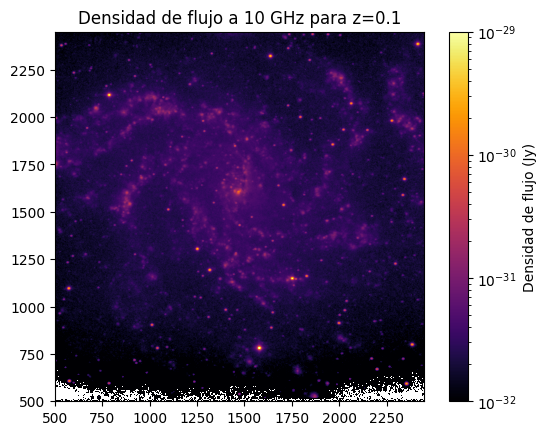

Valor maximo de la imagen: 2.996532609879723e-29
Valor minimo de la imagen: -1.8012928718710684e-32


In [239]:
imagen_01 = luminosity_to_flux_2(lum_1_4GHz, z_01, alpha)

plt.imshow(imagen_01, norm=LogNorm(vmin=1e-32, vmax=1e-29), cmap='inferno', origin='lower')
plt.colorbar(label='Densidad de flujo (Jy)')
plt.title(f'Densidad de flujo a 10 GHz para z={z_01}')
plt.xlim(500, 2450)
plt.ylim(500, 2450)
plt.show()

print("Valor maximo de la imagen:", np.max(imagen_01))
print("Valor minimo de la imagen:", np.min(imagen_01))

#guardar imagen en formato FITS
#vamos a guardar los datos de la imagen original
header_original = sfr_fits[0].header.copy()

header_original['BUNIT'] = 'Jy/pixel'                   # nuevas unidades
header_original['OBJECT'] = f'Model z={z_01}'           # Descripción
header_original['HISTORY'] = 'Converted from Halpha to 10GHz flux'


Ahora vamos con la conversión de escalas:

Queremos simular cómo se vería una galaxia a un redshift de **z = 0.1**, manteniendo un tamaño físico de **30 kpc × 30 kpc**, y partimos de una imagen original de **2900 px × 2900 px**.

Si consideramos que la galaxia ocupa 30 kpc de lado y está muestreada en 2900 píxeles, entonces:

$$
\text{Escala física por píxel} = \frac{30 \, \text{kpc}}{2900 \, \text{pix}} \approx 0.01034 \, \text{kpc/pix}
$$

Usando la calculadora cosmológica de Ned Wright ([link](https://www.astro.ucla.edu/~wright/CosmoCalc.html)), obtenemos para z = 1:

$$
1 \, \text{arcsec} = 1.857 \, \text{kpc}
$$

Tamaño angular aparente de la galaxia:

$$
30 \, \text{kpc} \div 1.857 \, \text{kpc/arcsec} = 16.15 \, \text{arcsec}
$$

Escala angular por píxel (arcsec/pix)

$$
\frac{16.15 \, \text{arcsec}}{2900 \, \text{pix}} \approx 0.0055 \, \text{arcsec/pix}
$$


In [253]:
#Primero abrimos el archivo de z=0.1
archivo_z01 = 'flux_z01.fits'
hdul_z01 = fits.open(archivo_z01)
data_z01 = hdul_z01[0].data
header_z01 = hdul_z01[0].header.copy() #hacemos una copia

for key in ['RA', 'DEC']:
    if key in header_z01:
        del header_z01[key]
    
# escala angular simulando z=0.1
arcsec_per_pixel_z01 = 0.005568
deg_per_pixel_z01 = arcsec_per_pixel_z01 / 3600

# Modificar Headers
header_z01['CDELT1'] = -deg_per_pixel_z01
header_z01['CDELT2'] = deg_per_pixel_z01
header_z01['CTYPE1'] = 'RA---TAN'    
header_z01['CTYPE2'] = 'DEC--TAN'    

header_z01['COMMENT'] = 'Escala de pixes ajustada para z=0.1'

# Guardar
fits.writeto('flux_z01.fits', data_z01, header_z01, overwrite=True)
hdul_z01.close()

print(deg_per_pixel_z01)



1.5466666666666668e-06


Ahora vamos a realizarle el filtrado

Para una imagen del VLA con una resolución de 0.2 arcsec se alcanza una sensitividad de ~0.8uJy/beam
Para una imagen del ngVLA con una resolución de 0.05 arcsec se alcanza 0.05uJy/beam. 

Esto es para 10GHz, obtenido con las calculadoras de sensibilidad del VLA y ngVLA

entonces, en las imágenes se verá que todo lo que esté por debajo de 3 veces  ese valor aparezca en negro

In [242]:
# Para hacer esto necesitamos las imagenes convolucionadas a la resolucion del VLA y del ngVLA 
# que obtendremos con CASA

## Para redshift z=0.5

In [243]:
#Haremos la conversión para un z en concreto, en este caso z=1
z_05 = 0.5

# Sumamos los valores para obtener la densidad de flujo total
flujo_total = np.sum(luminosity_to_flux_2(lum_1_4GHz, z_05, alpha))
print(f"Densidad de flujo total a 10 GHz: {flujo_total:.2e} erg/s/cm^2/Hz")

# Convertir de erg/s/cm^2/Hz a Jy
flujo_total_jy = flujo_total * 1e23
print(f"Densidad de flujo total a 10 GHz: {flujo_total_jy:.2e} Jy")

Densidad de flujo total a 10 GHz: 3.05e-27 erg/s/cm^2/Hz
Densidad de flujo total a 10 GHz: 3.05e-04 Jy


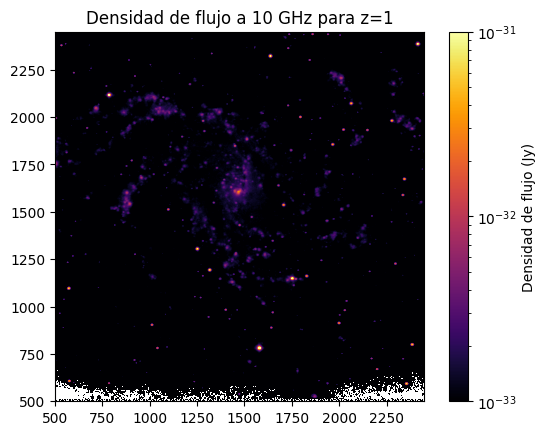

Valor maximo de la imagen: 8.682982199322797e-31
Valor minimo de la imagen: -5.219564335088479e-34


In [244]:
imagen_05 = luminosity_to_flux_2(lum_1_4GHz, z_05, alpha)

plt.imshow(imagen_05, norm=LogNorm(vmin=1e-33, vmax=1e-31), cmap='inferno', origin='lower')
plt.colorbar(label='Densidad de flujo (Jy)')
plt.title(f'Densidad de flujo a 10 GHz para z={z_1}')
plt.xlim(500, 2450)
plt.ylim(500, 2450)
plt.show()

print("Valor maximo de la imagen:", np.max(imagen_05))
print("Valor minimo de la imagen:", np.min(imagen_05))

#guardar imagen en formato FITS
hdu = fits.PrimaryHDU(imagen_05)
hdu.writeto('flux_z05.fits', overwrite=True)

## Para redshift z=1

In [245]:
#Haremos la conversión para un z en concreto, en este caso z=1
z_1 = 1

# Sumamos los valores para obtener la densidad de flujo total
flujo_total = np.sum(luminosity_to_flux_2(lum_1_4GHz, z_1, alpha))
print(f"Densidad de flujo total a 10 GHz: {flujo_total:.2e} erg/s/cm^2/Hz")

# Convertir de erg/s/cm^2/Hz a Jy
flujo_total_jy = flujo_total * 1e23
print(f"Densidad de flujo total a 10 GHz: {flujo_total_jy:.2e} Jy")

Densidad de flujo total a 10 GHz: 6.11e-28 erg/s/cm^2/Hz
Densidad de flujo total a 10 GHz: 6.11e-05 Jy


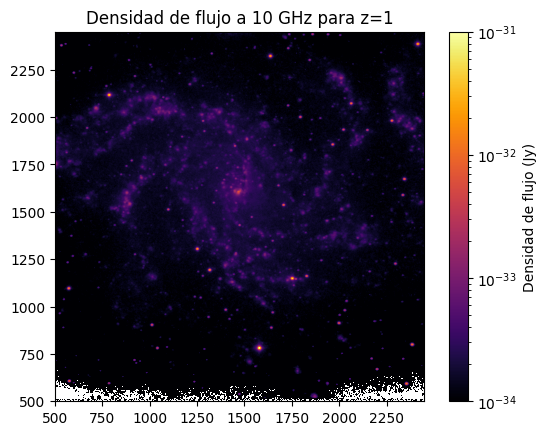

Valor maximo de la imagen: 1.740078497136826e-31
Valor minimo de la imagen: -1.0460060173065999e-34


In [246]:
imagen_1 = luminosity_to_flux_2(lum_1_4GHz, z_1, alpha)

plt.imshow(imagen_1, norm=LogNorm(vmin=1e-34, vmax=1e-31), cmap='inferno', origin='lower')
plt.colorbar(label='Densidad de flujo (Jy)')
plt.title(f'Densidad de flujo a 10 GHz para z={z_1}')
plt.xlim(500, 2450)
plt.ylim(500, 2450)
plt.show()

print("Valor maximo de la imagen:", np.max(imagen_1))
print("Valor minimo de la imagen:", np.min(imagen_1))

#guardar imagen en formato FITS
hdu = fits.PrimaryHDU(imagen_1)
hdu.writeto('flux_z1.fits', overwrite=True)

Ahora vamos a realizarle el filtrado

Para una imagen del VLA con una resolución de 0.2 arcsec se alcanza una sensitividad de ~0.8uJy/beam
Para una imagen del ngVLA con una resolución de 0.05 arcsec se alcanza 0.05uJy/beam. 

Esto es para 10GHz, obtenido con las calculadoras de sensibilidad del VLA y ngVLA

entonces, en las imágenes se verá que todo lo que esté por debajo de 3 veces  ese valor aparezca en negro

In [247]:
# Para hacer esto necesitamos las imagenes convolucionadas a la resolucion del VLA y del ngVLA 
# que obtendremos con CASA

## Para redshift de z = 3

In [248]:
#Haremos la conversión para un z en concreto, en este caso z=1
z_3 = 3

# Sumamos los valores para obtener la densidad de flujo total
flujo_total = np.sum(luminosity_to_flux_2(lum_1_4GHz, z_3, alpha))
print(f"Densidad de flujo total a 10 GHz: {flujo_total:.2e} erg/s/cm^2/Hz")

# Convertir de erg/s/cm^2/Hz a Jy
flujo_total_jy = flujo_total * 1e23
print(f"Densidad de flujo total a 10 GHz: {flujo_total_jy:.2e} Jy")

Densidad de flujo total a 10 GHz: 5.08e-29 erg/s/cm^2/Hz
Densidad de flujo total a 10 GHz: 5.08e-06 Jy


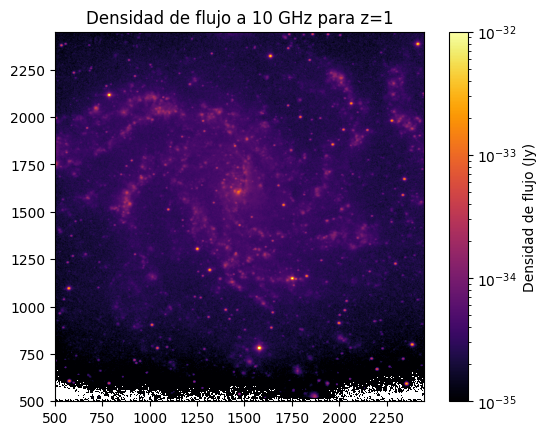

Valor maximo de la imagen: 1.4475681592221042e-32
Valor minimo de la imagen: -8.701705189562786e-36


In [249]:
imagen_3 = luminosity_to_flux_2(lum_1_4GHz, z_3, alpha)

plt.imshow(imagen_2, norm=LogNorm(vmin=1e-35, vmax=1e-32), cmap='inferno', origin='lower')
plt.colorbar(label='Densidad de flujo (Jy)')
plt.title(f'Densidad de flujo a 10 GHz para z={z_1}')
plt.xlim(500, 2450)
plt.ylim(500, 2450)
plt.show()

print("Valor maximo de la imagen:", np.max(imagen_3))
print("Valor minimo de la imagen:", np.min(imagen_3))

#guardar imagen en formato FITS
hdu = fits.PrimaryHDU(imagen_3)
hdu.writeto('flux_z3.fits', overwrite=True)

Ahora vamos a realizarle el filtrado

Para una imagen del VLA con una resolución de 0.2 arcsec se alcanza una sensitividad de ~0.8uJy/beam
Para una imagen del ngVLA con una resolución de 0.05 arcsec se alcanza 0.05uJy/beam. 

Esto es para 10GHz, obtenido con las calculadoras de sensibilidad del VLA y ngVLA

entonces, en las imágenes se verá que todo lo que esté por debajo de 3 veces  ese valor aparezca en negro

In [250]:
# Para hacer esto necesitamos las imagenes convolucionadas a la resolucion del VLA y del ngVLA 
# que obtendremos con CASA

## Para redshift z=5

In [251]:
#Haremos la conversión para un z en concreto, en este caso z=1
z_5 = 5

# Sumamos los valores para obtener la densidad de flujo total
flujo_total = np.sum(luminosity_to_flux_2(lum_1_4GHz, z_5, alpha))
print(f"Densidad de flujo total a 10 GHz: {flujo_total:.2e} erg/s/cm^2/Hz")

# Convertir de erg/s/cm^2/Hz a Jy
flujo_total_jy = flujo_total * 1e23
print(f"Densidad de flujo total a 10 GHz: {flujo_total_jy:.2e} Jy")

Densidad de flujo total a 10 GHz: 1.71e-29 erg/s/cm^2/Hz
Densidad de flujo total a 10 GHz: 1.71e-06 Jy


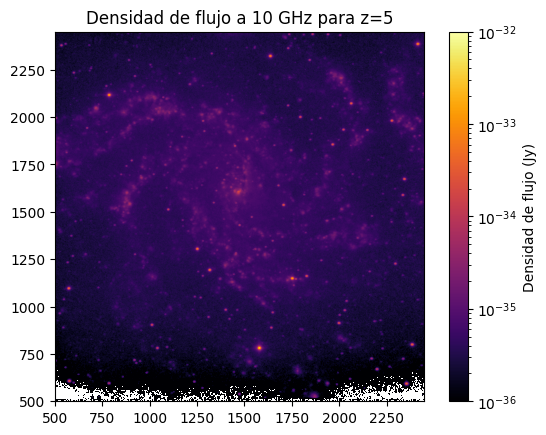

Valor maximo de la imagen: 4.855563712724639e-33
Valor minimo de la imagen: -2.9188043838152803e-36


In [252]:
imagen_5 = luminosity_to_flux_2(lum_1_4GHz, z_5, alpha)

plt.imshow(imagen_5, norm=LogNorm(vmin=1e-36, vmax=1e-32), cmap='inferno', origin='lower')
plt.colorbar(label='Densidad de flujo (Jy)')
plt.title(f'Densidad de flujo a 10 GHz para z={z_5}')
plt.xlim(500, 2450)
plt.ylim(500, 2450)
plt.show()

print("Valor maximo de la imagen:", np.max(imagen_5))
print("Valor minimo de la imagen:", np.min(imagen_5))

#guardar imagen en formato FITS
hdu = fits.PrimaryHDU(imagen_5)
hdu.writeto('flux_z5.fits', overwrite=True)